# Final Portfolio Project - Regression Task
# BMI Prediction Using Heart Attack Prediction Dataset

**Student Name:** Srijan Pokhrel  
**UID:** 2548386  
**Course:** Concepts and Technologies of AI (5CS037)  
**Module:** Final Portfolio Project  

---
## Task 1: Exploratory Data Analysis and Data Understanding
### 1.1 Choosing a Dataset

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Load the dataset
df = pd.read_csv('/content/heart_attack_prediction_dataset.csv')

# Display basic information
print('Shape of dataset:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape of dataset: (8763, 26)

First 5 rows:


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [ ]:
# Dataset info
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet  

In [ ]:
# Check for missing values
print('Missing Values per Column:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {df.isnull().sum().sum()}')
print(f'Total records: {len(df)}')
print(f'Total features: {df.shape[1]}')

Missing Values per Column:
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []

Total missing values: 0
Total records: 8763
Total features: 26


In [ ]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

# Check data types
print('\nData Types:')
print(df.dtypes)

Duplicate rows: 0

Data Types:
Patient ID                          object
Age                                  int64
Sex                                 object
Cholesterol                          int64
Blood Pressure                      object
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                object
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Country                

### 1.2 Exploratory Data Analysis (EDA)

#### (a) Data Cleaning and Preprocessing

In [ ]:
# Drop Patient ID as it is not a useful feature
df = df.drop('Patient ID', axis=1)

# Parse Blood Pressure into Systolic and Diastolic
df[['BP_Systolic', 'BP_Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)
df = df.drop('Blood Pressure', axis=1)

print('Blood Pressure parsed into BP_Systolic and BP_Diastolic.')
print(df[['BP_Systolic', 'BP_Diastolic']].head())

Blood Pressure parsed into BP_Systolic and BP_Diastolic.
   BP_Systolic  BP_Diastolic
0        158.0          88.0
1        165.0          93.0
2        174.0          99.0
3        163.0         100.0
4         91.0          88.0


In [ ]:
# Drop high-cardinality categorical columns that add noise
df = df.drop(['Country', 'Continent', 'Hemisphere'], axis=1)

# Encode categorical variables
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

le_diet = LabelEncoder()
df['Diet'] = le_diet.fit_transform(df['Diet'])

print('Categorical encoding applied.')
print(f'Sex mapping: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}')
print(f'Diet mapping: {dict(zip(le_diet.classes_, le_diet.transform(le_diet.classes_)))}')

Categorical encoding applied.
Sex mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
Diet mapping: {'Average': np.int64(0), 'Healthy': np.int64(1), 'Unhealthy': np.int64(2)}


In [ ]:
# Check and handle missing values after preprocessing
print('Missing values after preprocessing:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill numeric missing values with median
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print('\nMissing values after imputation:', df.isnull().sum().sum())

Missing values after preprocessing:
Series([], dtype: int64)

Missing values after imputation: 0


In [ ]:
# Summary statistics
print('Summary Statistics:')
df.describe().round(2)

Summary Statistics:


,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,BP_Systolic,BP_Diastolic
count,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00,8763.0,8763.0,8763.00,8763.00,...,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00,8763.00
mean,53.71,0.70,259.88,75.02,0.65,0.49,0.9,0.5,0.60,10.01,...,5.47,5.99,158263.18,28.89,417.68,3.49,7.02,0.36,135.08,85.16
std,21.25,0.46,80.86,20.55,0.48,0.50,0.3,0.5,0.49,5.78,...,2.86,3.47,80575.19,6.32,223.75,2.28,1.99,0.48,26.35,14.68
min,18.00,0.00,120.00,40.00,0.00,0.00,0.0,0.0,0.00,0.00,...,1.00,0.00,20062.00,18.00,30.00,0.00,4.00,0.00,90.00,60.00
25%,35.00,0.00,192.00,57.00,0.00,0.00,1.0,0.0,0.00,4.98,...,3.00,3.00,88310.00,23.42,225.50,2.00,5.00,0.00,112.00,72.00
50%,54.00,1.00,259.00,75.00,1.00,0.00,1.0,1.0,1.00,10.07,...,5.00,5.93,157866.00,28.77,417.00,3.00,7.00,0.00,135.00,85.00
75%,72.00,1.00,330.00,93.00,1.00,1.00,1.0,1.0,1.00,15.05,...,8.00,9.02,227749.00,34.32,612.00,5.00,9.00,1.00,158.00,98.00
max,90.00,1.00,400.00,110.00,1.00,1.00,1.0,1.0,1.00,20.00,...,10.00,12.00,299954.00,40.00,800.00,7.00,10.00,1.00,180.00,110.00


#### (b) Visualizations to Summarize, Explore, and Understand the Data

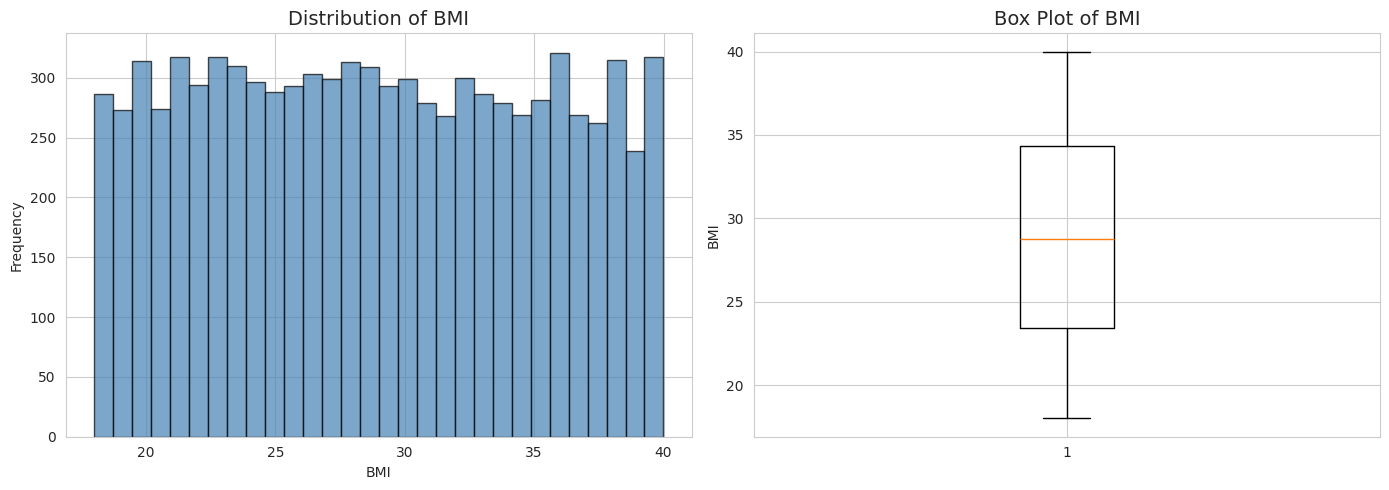

BMI Mean: 28.89
BMI Median: 28.77
BMI Std Dev: 6.32
BMI Min: 18.00, Max: 40.00


In [ ]:
# 1. Distribution of Target Variable (BMI)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['BMI'], bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_title('Distribution of BMI', fontsize=14)
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['BMI'], vert=True)
axes[1].set_title('Box Plot of BMI', fontsize=14)
axes[1].set_ylabel('BMI')

plt.tight_layout()
plt.show()

print(f'BMI Mean: {df["BMI"].mean():.2f}')
print(f'BMI Median: {df["BMI"].median():.2f}')
print(f'BMI Std Dev: {df["BMI"].std():.2f}')
print(f'BMI Min: {df["BMI"].min():.2f}, Max: {df["BMI"].max():.2f}')

**Insight:** The BMI distribution appears approximately uniform across the range of 18-40. The box plot shows the spread of BMI values with the median around the center.

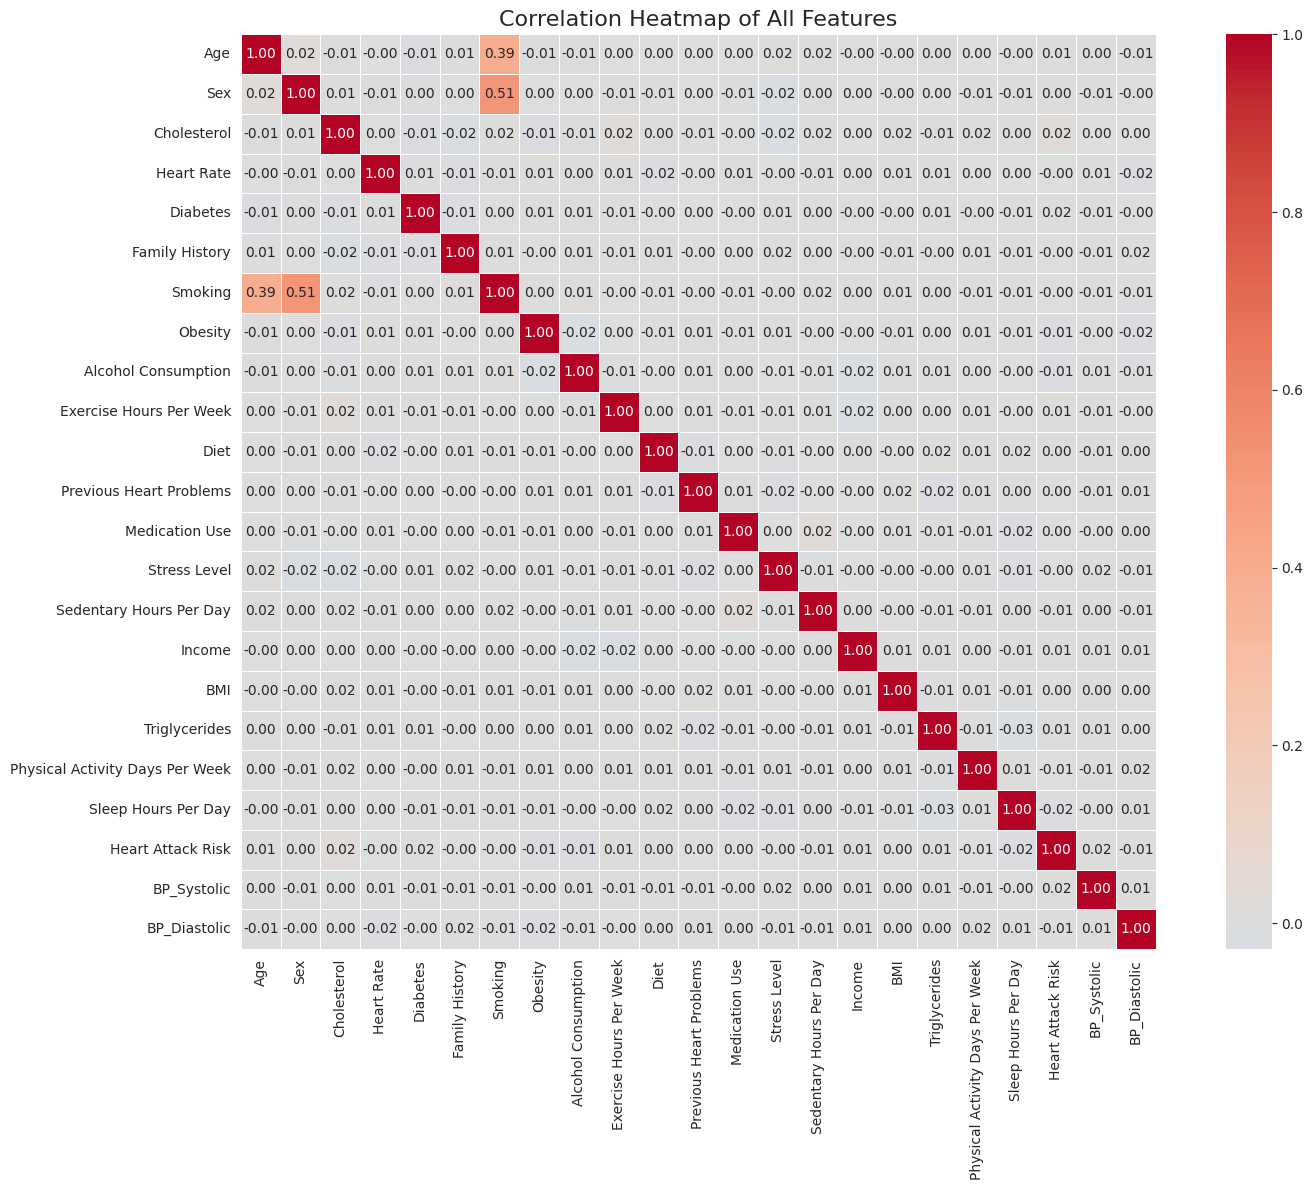

In [ ]:
# 2. Correlation Heatmap
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.tight_layout()
plt.show()

**Insight:** The correlation heatmap helps identify which features have linear relationships with BMI. Features with higher absolute correlation values are potentially better predictors for our regression models.

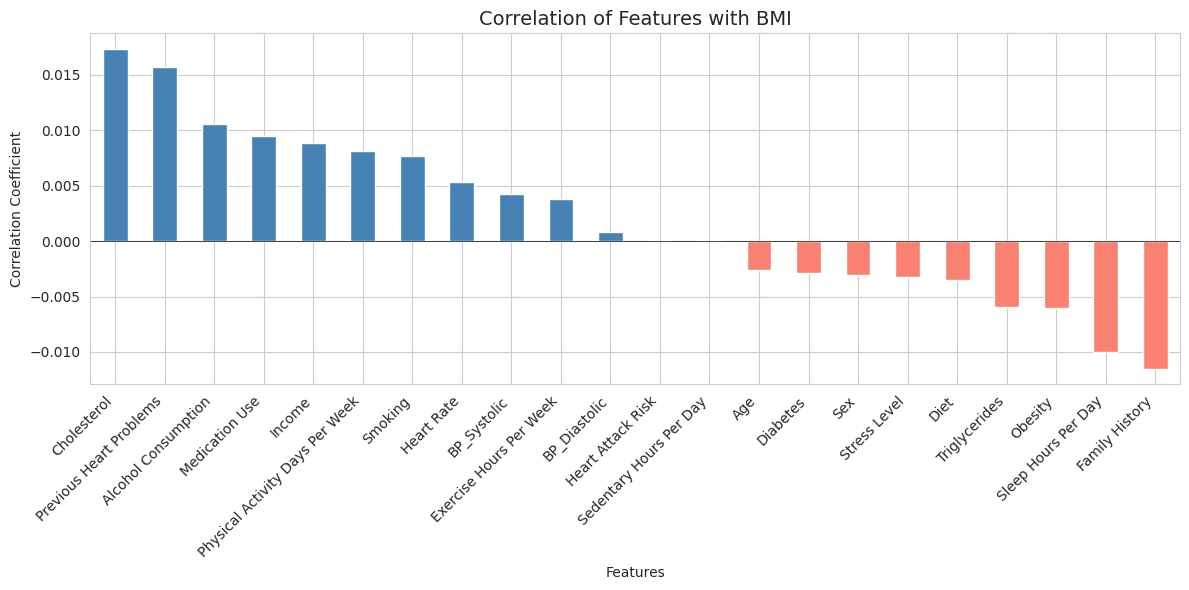

Top 5 positively correlated features with BMI:
Cholesterol                0.017292
Previous Heart Problems    0.015718
Alcohol Consumption        0.010562
Medication Use             0.009514
Income                     0.008836
Name: BMI, dtype: float64

Top 5 negatively correlated features with BMI:
Diet                  -0.003544
Triglycerides         -0.005964
Obesity               -0.006058
Sleep Hours Per Day   -0.010030
Family History        -0.011492
Name: BMI, dtype: float64


In [ ]:
# 3. Correlation of features with BMI (target)
bmi_corr = correlation_matrix['BMI'].drop('BMI').sort_values(ascending=False)
plt.figure(figsize=(12, 6))
bmi_corr.plot(kind='bar', color=['steelblue' if x >= 0 else 'salmon' for x in bmi_corr])
plt.title('Correlation of Features with BMI', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Top 5 positively correlated features with BMI:')
print(bmi_corr.head())
print('\nTop 5 negatively correlated features with BMI:')
print(bmi_corr.tail())

**Insight:** This bar chart reveals the strength and direction of linear relationships between each feature and the target variable BMI. Features with higher absolute correlation may serve as stronger predictors.

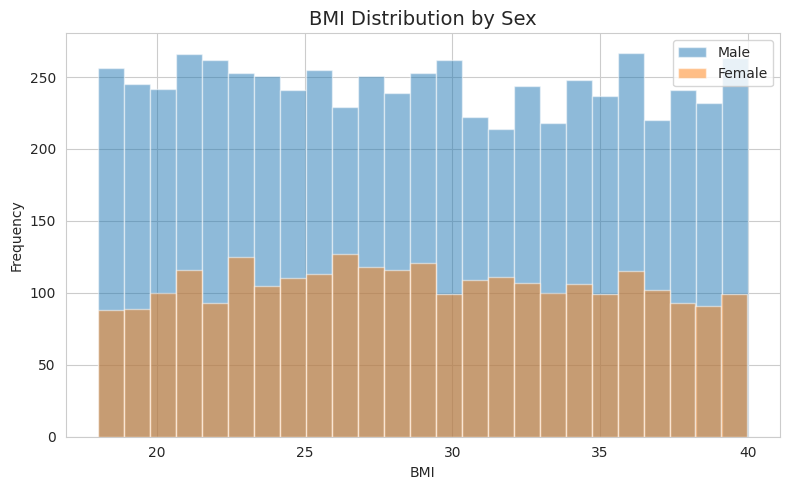

In [ ]:
# 4. BMI distribution by Sex
plt.figure(figsize=(8, 5))
sex_labels = {0: 'Female', 1: 'Male'}
for sex_val in df['Sex'].unique():
    subset = df[df['Sex'] == sex_val]['BMI']
    plt.hist(subset, bins=25, alpha=0.5, label=sex_labels.get(sex_val, str(sex_val)))

plt.title('BMI Distribution by Sex', fontsize=14)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** The overlapping distributions of BMI for males and females suggest that sex alone may not be a dominant predictor of BMI.

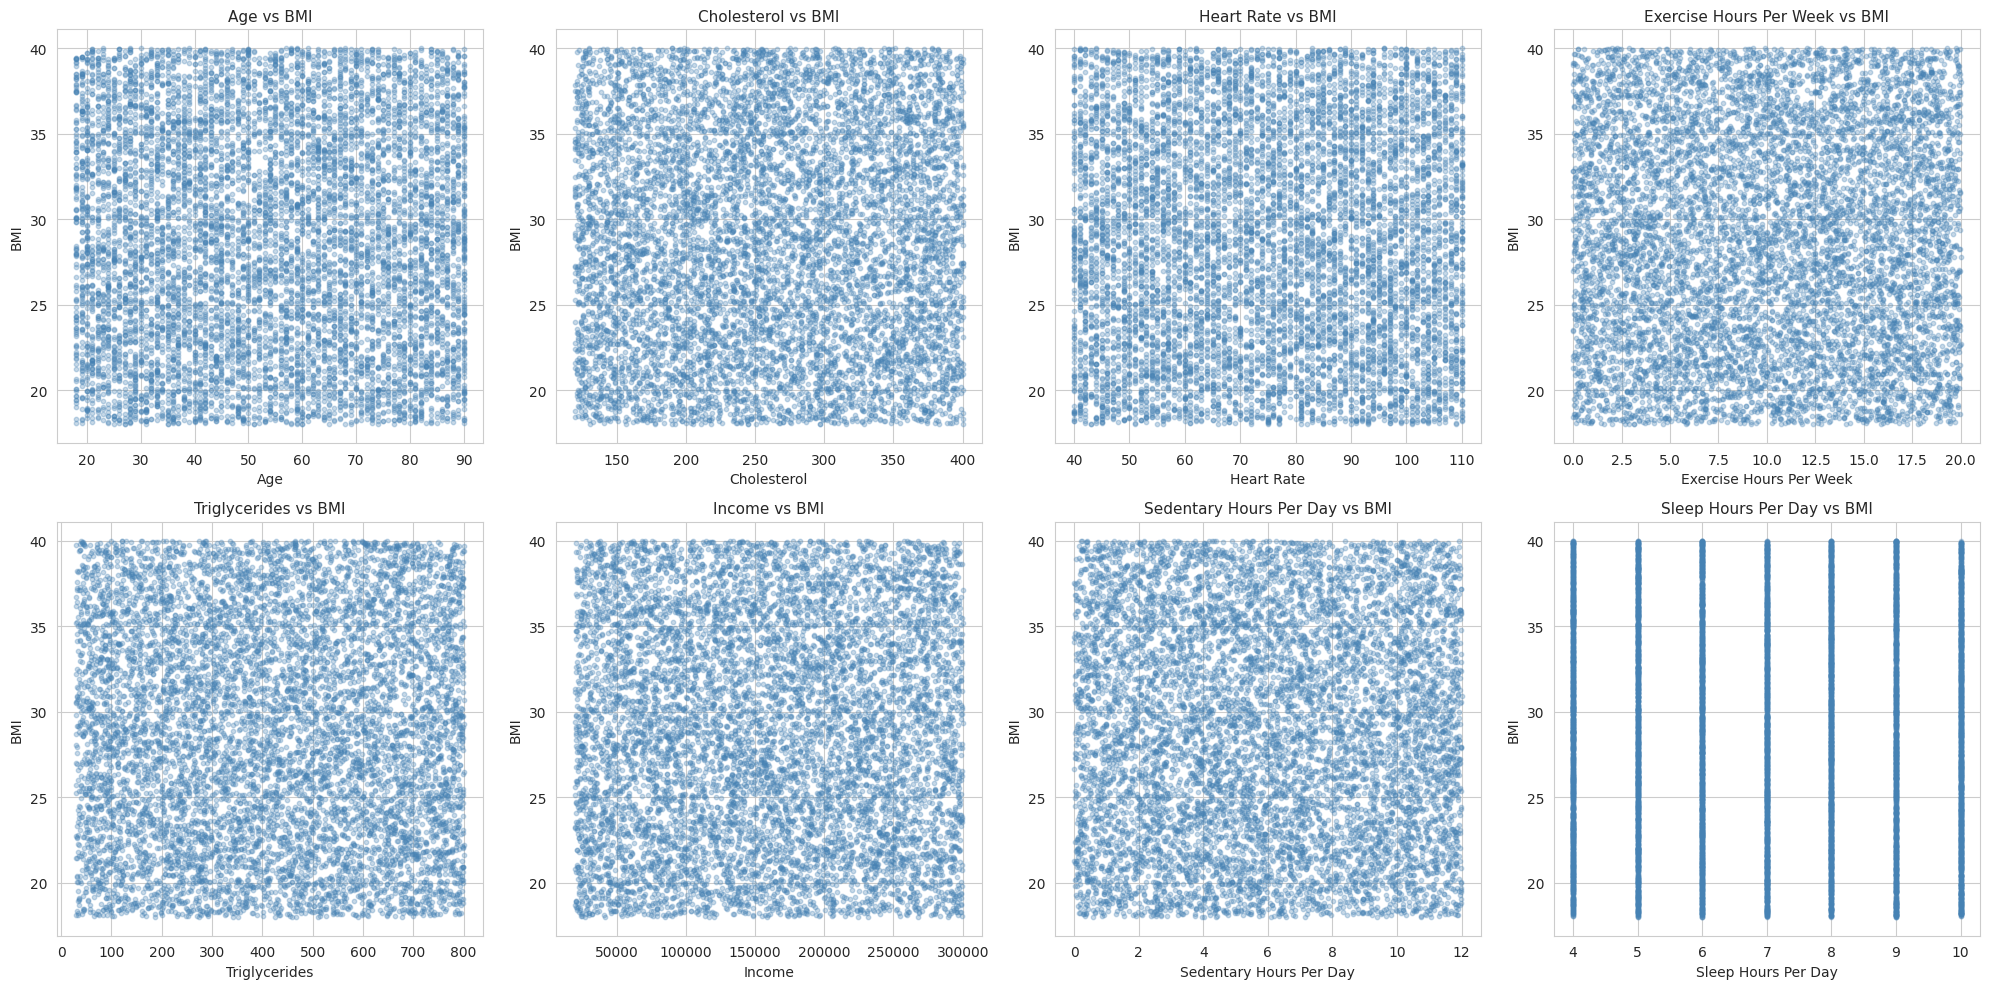

In [ ]:
# 5. Scatter plots of key numerical features vs BMI
numerical_features = ['Age', 'Cholesterol', 'Heart Rate', 'Exercise Hours Per Week',
                       'Triglycerides', 'Income', 'Sedentary Hours Per Day', 'Sleep Hours Per Day']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, feature in enumerate(numerical_features):
    row, col = i // 4, i % 4
    axes[row, col].scatter(df[feature], df['BMI'], alpha=0.3, s=10, color='steelblue')
    axes[row, col].set_title(f'{feature} vs BMI', fontsize=11)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('BMI')

plt.tight_layout()
plt.show()

**Insight:** The scatter plots show the relationships between key numerical features and BMI. This helps identify potential non-linear patterns that may be captured by more complex models like Random Forest.

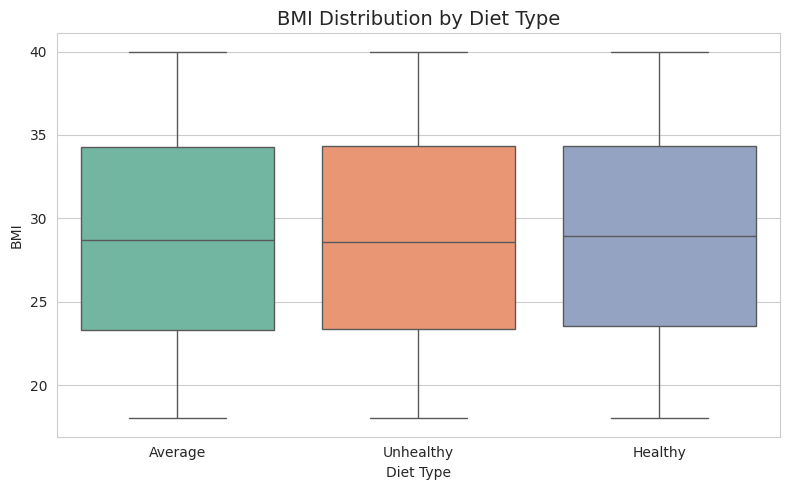

In [ ]:
# 6. BMI by Diet type
plt.figure(figsize=(8, 5))
diet_names = dict(zip(le_diet.transform(le_diet.classes_), le_diet.classes_))
df_temp = df.copy()
df_temp['Diet_Name'] = df_temp['Diet'].map(diet_names)
sns.boxplot(x='Diet_Name', y='BMI', data=df_temp, palette='Set2')
plt.title('BMI Distribution by Diet Type', fontsize=14)
plt.xlabel('Diet Type')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

**Insight:** The box plot compares BMI distributions across different diet types. This visualization helps understand if dietary habits have a noticeable effect on BMI.

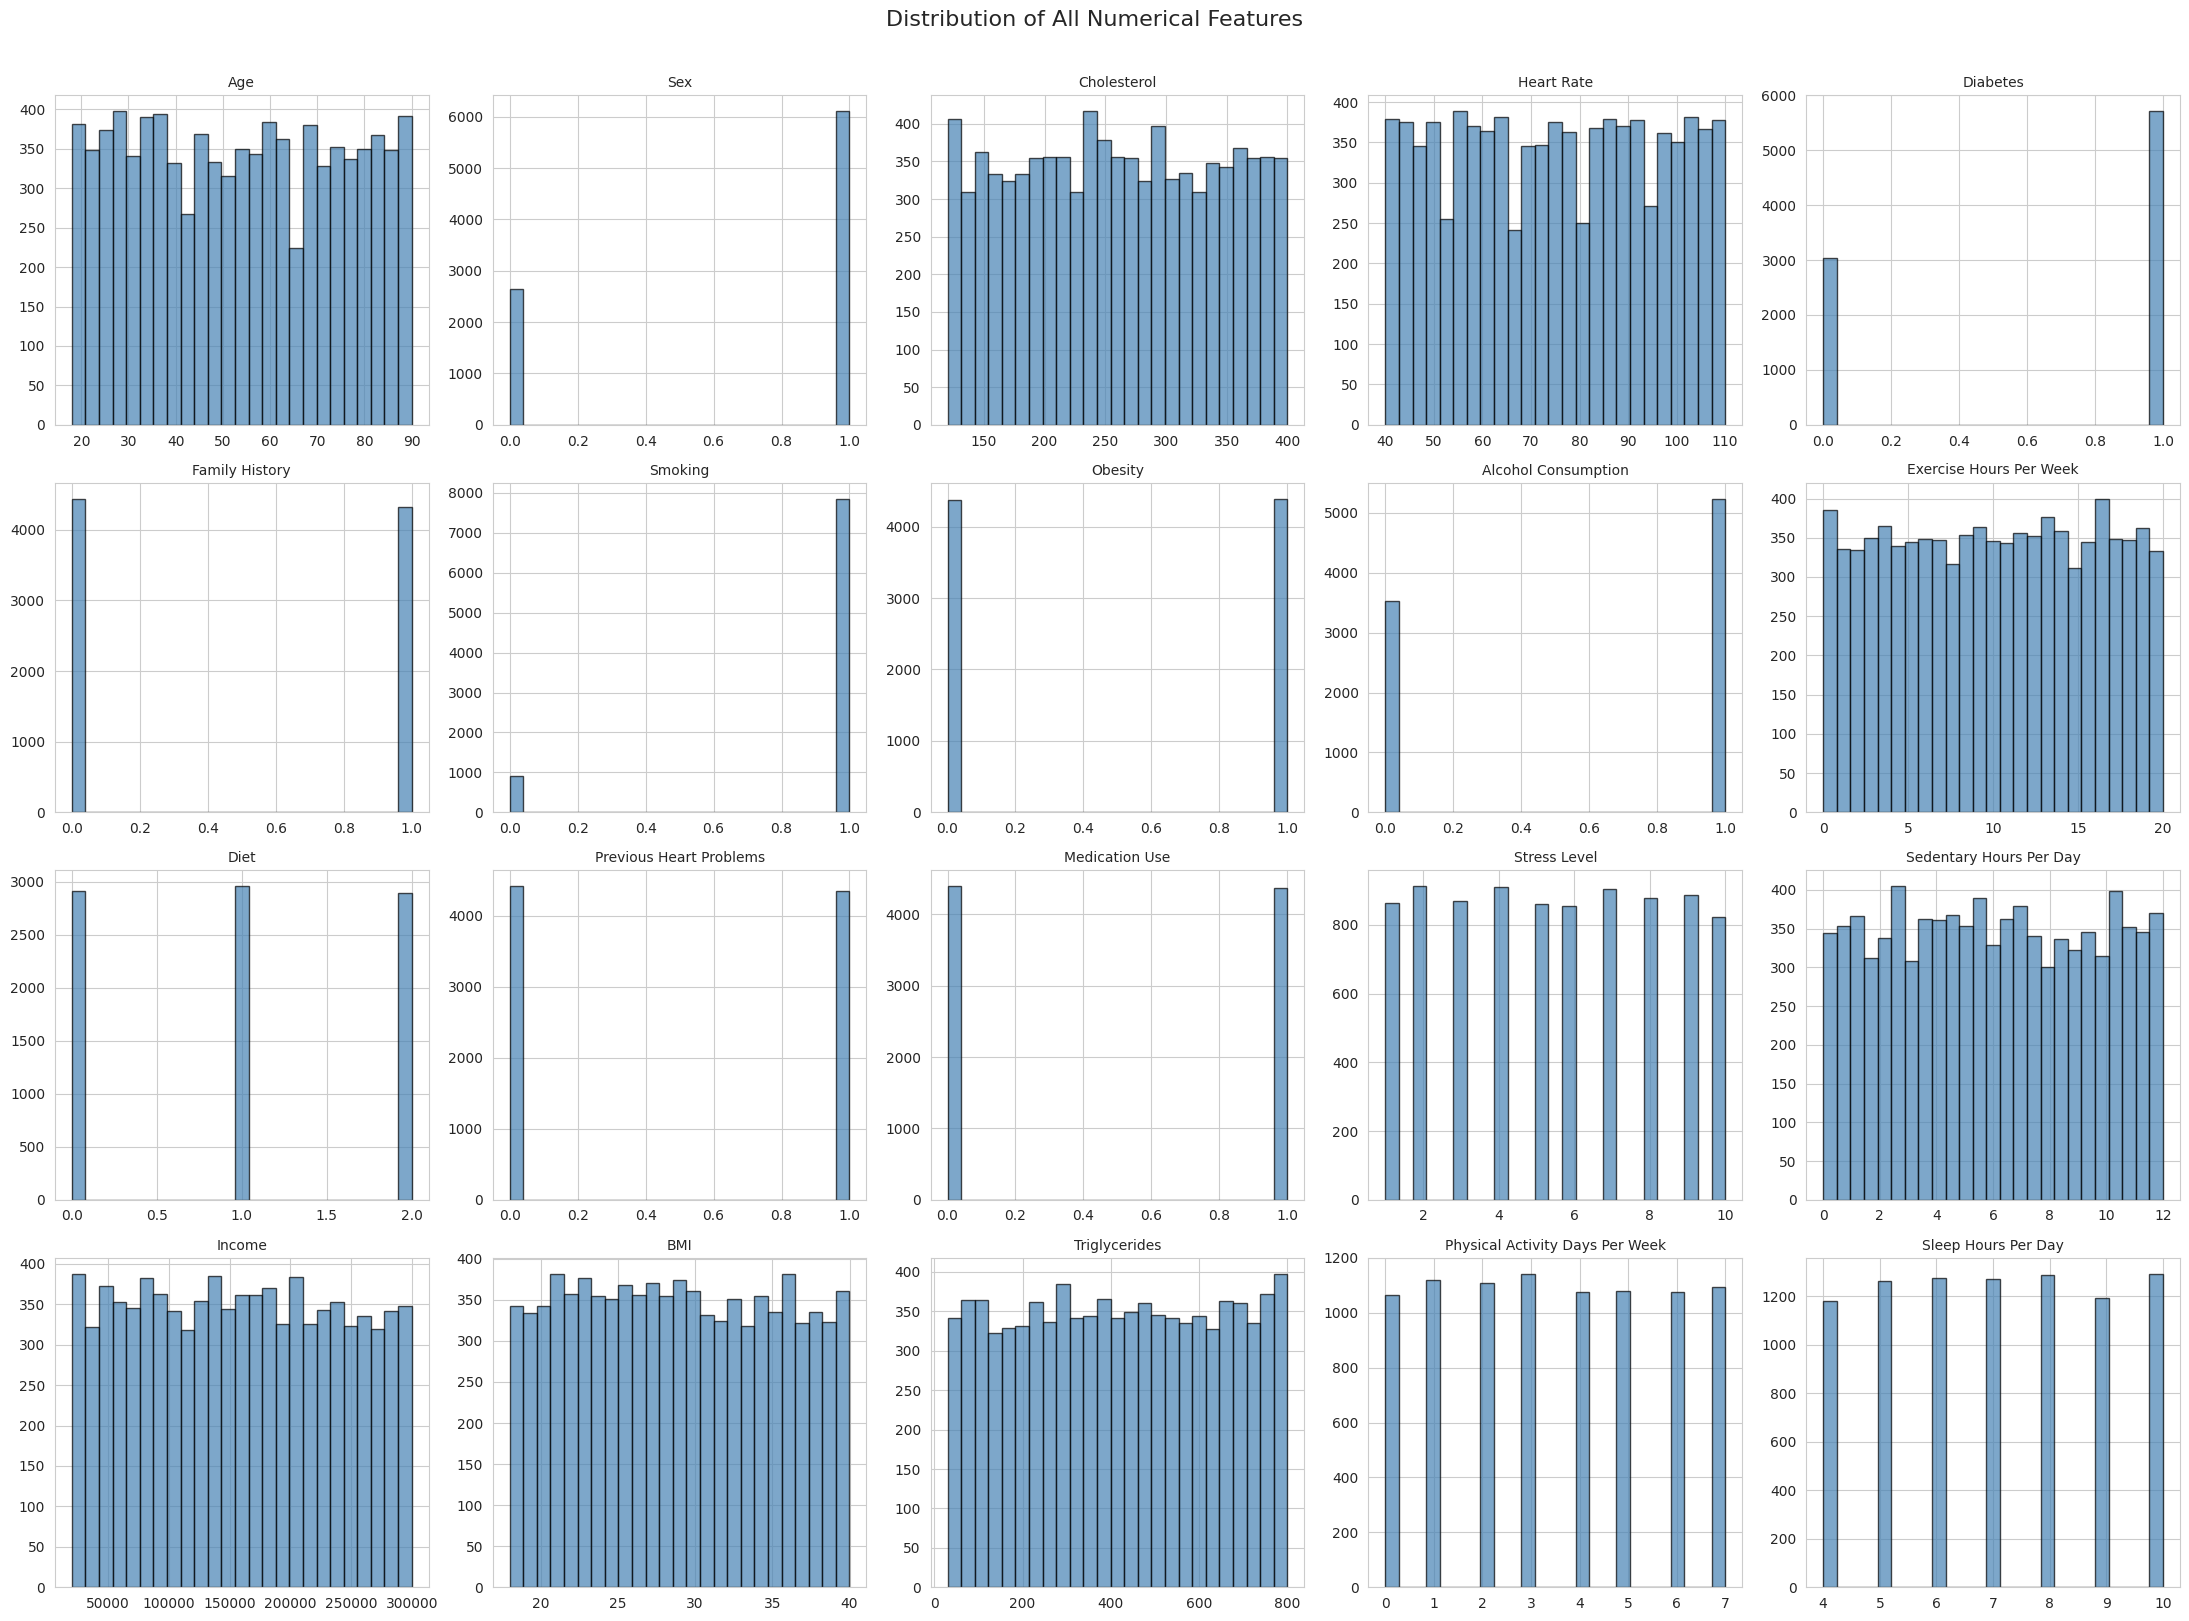

In [ ]:
# 7. Distribution of numerical features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    if i < len(axes):
        axes[i].hist(df[col], bins=25, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(col, fontsize=10)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distribution of All Numerical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## Task 2: Build a Neural Network Model for Regression

In [ ]:
# Prepare features and target
X = df.drop('BMI', axis=1)
y = df['BMI']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature names: {list(X.columns)}')

Features shape: (8763, 22)
Target shape: (8763,)
Feature names: ['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Heart Attack Risk', 'BP_Systolic', 'BP_Diastolic']


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

Training set size: 7010
Testing set size: 1753


In [ ]:
# Scale features for Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling applied using StandardScaler.')

Feature scaling applied using StandardScaler.


In [ ]:
# Build and train the Neural Network
nn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)
print('Neural Network model trained successfully.')

Neural Network model trained successfully.


In [ ]:
# Evaluate Neural Network on Training Set
y_train_pred_nn = nn_model.predict(X_train_scaled)
print('=== Neural Network - Training Set Performance ===')
print(f'MSE:  {mean_squared_error(y_train, y_train_pred_nn):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_nn)):.4f}')
print(f'MAE:  {mean_absolute_error(y_train, y_train_pred_nn):.4f}')
print(f'R-squared: {r2_score(y_train, y_train_pred_nn):.4f}')

=== Neural Network - Training Set Performance ===
MSE:  36.2924
RMSE: 6.0243
MAE:  5.1483
R-squared: 0.0867


In [ ]:
# Evaluate Neural Network on Test Set
y_test_pred_nn = nn_model.predict(X_test_scaled)
print('=== Neural Network - Test Set Performance ===')
print(f'MSE:  {mean_squared_error(y_test, y_test_pred_nn):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_nn)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_test_pred_nn):.4f}')
print(f'R-squared: {r2_score(y_test, y_test_pred_nn):.4f}')

=== Neural Network - Test Set Performance ===
MSE:  43.8926
RMSE: 6.6252
MAE:  5.6804
R-squared: -0.0792


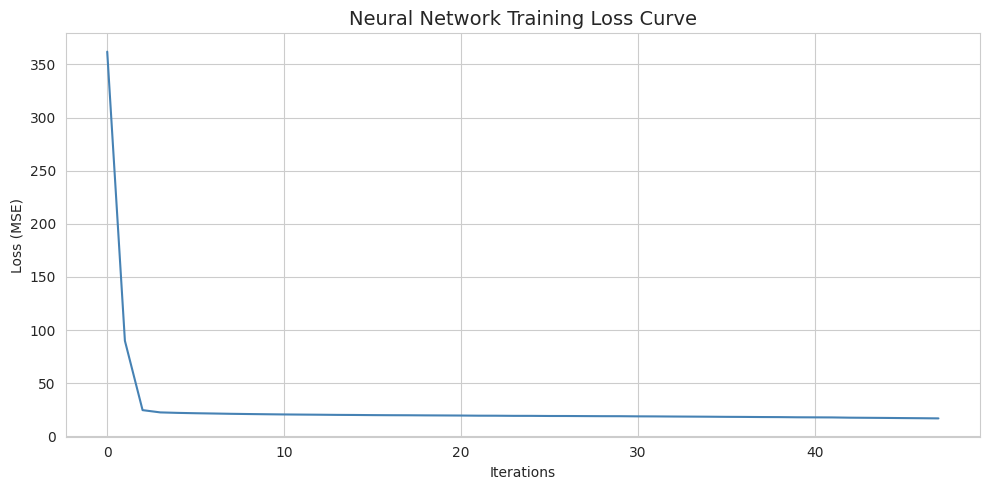

In [ ]:
# Plot training loss curve
plt.figure(figsize=(10, 5))
plt.plot(nn_model.loss_curve_, color='steelblue')
plt.title('Neural Network Training Loss Curve', fontsize=14)
plt.xlabel('Iterations')
plt.ylabel('Loss (MSE)')
plt.tight_layout()
plt.show()

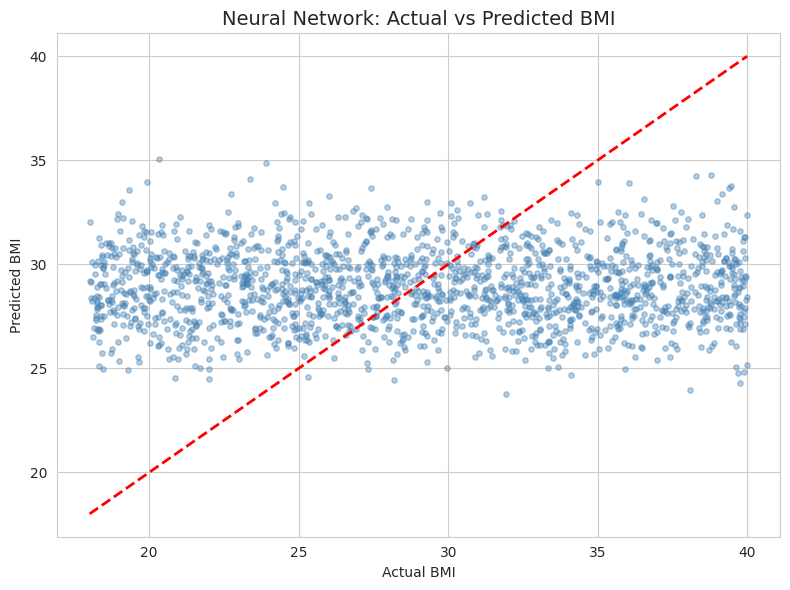

In [ ]:
# Actual vs Predicted plot for Neural Network
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_nn, alpha=0.4, s=15, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Neural Network: Actual vs Predicted BMI', fontsize=14)
plt.xlabel('Actual BMI')
plt.ylabel('Predicted BMI')
plt.tight_layout()
plt.show()

---
## Task 3: Build Primary Machine Learning Models (Two Classical ML Models)

Two classical regression models are selected:
1. **Linear Regression** - A simple, interpretable baseline model.
2. **Random Forest Regressor** - An ensemble method that can capture non-linear relationships.

### 3.1 Split Dataset into Training and Testing Sets

In [ ]:
# Data already split above, reusing X_train, X_test, y_train, y_test
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')
print(f'Train/Test split ratio: 80/20')

Training samples: 7010
Testing samples: 1753
Train/Test split ratio: 80/20


### 3.2 Model A: Linear Regression

In [ ]:
# Build and train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Training set evaluation
print('=== Linear Regression - Training Set ===')
print(f'MSE:  {mean_squared_error(y_train, y_train_pred_lr):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_lr)):.4f}')
print(f'MAE:  {mean_absolute_error(y_train, y_train_pred_lr):.4f}')
print(f'R-squared: {r2_score(y_train, y_train_pred_lr):.4f}')

print('\n=== Linear Regression - Test Set ===')
print(f'MSE:  {mean_squared_error(y_test, y_test_pred_lr):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_lr)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_test_pred_lr):.4f}')
print(f'R-squared: {r2_score(y_test, y_test_pred_lr):.4f}')

=== Linear Regression - Training Set ===
MSE:  39.5995
RMSE: 6.2928
MAE:  5.4321
R-squared: 0.0035

=== Linear Regression - Test Set ===
MSE:  41.1826
RMSE: 6.4174
MAE:  5.5467
R-squared: -0.0126


### 3.3 Model B: Random Forest Regressor

In [ ]:
# Build and train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Training set evaluation
print('=== Random Forest Regressor - Training Set ===')
print(f'MSE:  {mean_squared_error(y_train, y_train_pred_rf):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_rf)):.4f}')
print(f'MAE:  {mean_absolute_error(y_train, y_train_pred_rf):.4f}')
print(f'R-squared: {r2_score(y_train, y_train_pred_rf):.4f}')

print('\n=== Random Forest Regressor - Test Set ===')
print(f'MSE:  {mean_squared_error(y_test, y_test_pred_rf):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_test_pred_rf):.4f}')
print(f'R-squared: {r2_score(y_test, y_test_pred_rf):.4f}')

=== Random Forest Regressor - Training Set ===
MSE:  5.7065
RMSE: 2.3888
MAE:  2.0345
R-squared: 0.8564

=== Random Forest Regressor - Test Set ===
MSE:  41.8152
RMSE: 6.4665
MAE:  5.5812
R-squared: -0.0282


### 3.4 Initial Comparison of Models

In [ ]:
# Initial comparison table
initial_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'Train RMSE': [
        np.sqrt(mean_squared_error(y_train, y_train_pred_lr)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_test_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
    ],
    'Train R-squared': [
        r2_score(y_train, y_train_pred_lr),
        r2_score(y_train, y_train_pred_rf)
    ],
    'Test R-squared': [
        r2_score(y_test, y_test_pred_lr),
        r2_score(y_test, y_test_pred_rf)
    ]
})

print('Initial Model Comparison:')
print(initial_comparison.to_string(index=False))

Initial Model Comparison:
                  Model  Train RMSE  Test RMSE  Train R-squared  Test R-squared
      Linear Regression    6.292816   6.417364         0.003483       -0.012609
Random Forest Regressor    2.388822   6.466470         0.856397       -0.028165


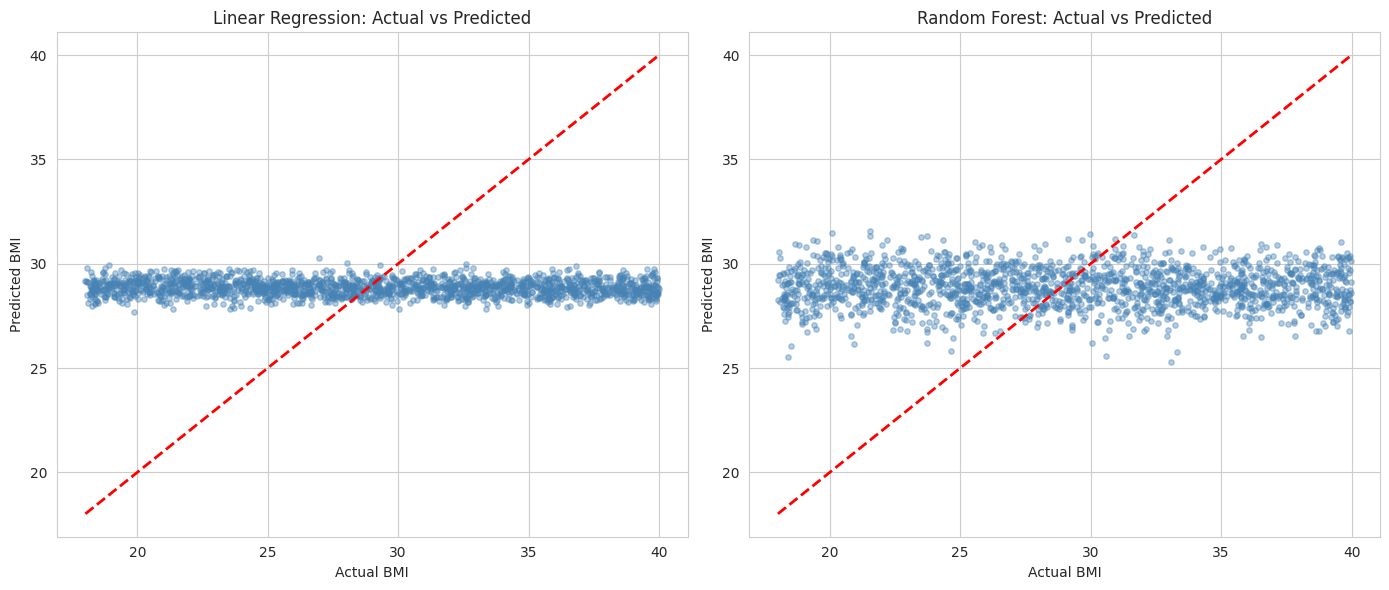

In [ ]:
# Visual comparison - Actual vs Predicted for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_test_pred_lr, alpha=0.4, s=15, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_title('Linear Regression: Actual vs Predicted', fontsize=12)
axes[0].set_xlabel('Actual BMI')
axes[0].set_ylabel('Predicted BMI')

axes[1].scatter(y_test, y_test_pred_rf, alpha=0.4, s=15, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_title('Random Forest: Actual vs Predicted', fontsize=12)
axes[1].set_xlabel('Actual BMI')
axes[1].set_ylabel('Predicted BMI')

plt.tight_layout()
plt.show()

**Initial Observation:** Comparing both models, the Random Forest Regressor is expected to outperform Linear Regression since it can capture non-linear relationships in the data. The actual vs predicted plots and metric comparison above confirm which model provides better predictions.

---
## Task 4: Hyperparameter Optimization with Cross-Validation

### 4.1 Hyperparameter Tuning for Linear Regression

Linear Regression has limited hyperparameters. We use Ridge Regression (L2 regularization) variant to enable tuning of the regularization parameter alpha.

In [ ]:
from sklearn.linear_model import Ridge

# Define parameter grid for Ridge Regression
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False]
}

ridge_model = Ridge()

# GridSearchCV for Ridge Regression
grid_search_ridge = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search_ridge.fit(X_train, y_train)

print('=== Ridge Regression (Linear) - Hyperparameter Tuning ===')
print(f'Best Parameters: {grid_search_ridge.best_params_}')
print(f'Best CV R-squared Score: {grid_search_ridge.best_score_:.4f}')

=== Ridge Regression (Linear) - Hyperparameter Tuning ===
Best Parameters: {'alpha': 100.0, 'fit_intercept': True}
Best CV R-squared Score: -0.0031


### 4.2 Hyperparameter Tuning for Random Forest Regressor

In [ ]:
# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_model = RandomForestRegressor(random_state=42)

# GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    estimator=rf_grid_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search_rf.fit(X_train, y_train)

print('=== Random Forest Regressor - Hyperparameter Tuning ===')
print(f'Best Parameters: {grid_search_rf.best_params_}')
print(f'Best CV R-squared Score: {grid_search_rf.best_score_:.4f}')

=== Random Forest Regressor - Hyperparameter Tuning ===
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R-squared Score: -0.0029


### 4.3 Summary of Best Hyperparameters and CV Scores

In [ ]:
print('\n=== Summary of Hyperparameter Optimization ===')
print(f'\nRidge Regression:')
print(f'  Best Parameters: {grid_search_ridge.best_params_}')
print(f'  Best CV Score (R-squared): {grid_search_ridge.best_score_:.4f}')

print(f'\nRandom Forest Regressor:')
print(f'  Best Parameters: {grid_search_rf.best_params_}')
print(f'  Best CV Score (R-squared): {grid_search_rf.best_score_:.4f}')


=== Summary of Hyperparameter Optimization ===

Ridge Regression:
  Best Parameters: {'alpha': 100.0, 'fit_intercept': True}
  Best CV Score (R-squared): -0.0031

Random Forest Regressor:
  Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV Score (R-squared): -0.0029


---
## Task 5: Feature Selection

In [ ]:
# Apply SelectKBest for feature selection
selector = SelectKBest(score_func=f_regression, k=10)
selector.fit(X_train, y_train)

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print('Feature Scores (SelectKBest with f_regression):')
print(feature_scores.to_string(index=False))

Feature Scores (SelectKBest with f_regression):
                        Feature  F-Score  p-value
        Previous Heart Problems 5.781888 0.016218
                         Income 2.811245 0.093650
            Sleep Hours Per Day 2.551418 0.110240
            Alcohol Consumption 2.465010 0.116452
                  Triglycerides 2.007879 0.156528
                        Obesity 1.427751 0.232172
                    Cholesterol 1.358222 0.243886
                           Diet 1.140526 0.285578
              Heart Attack Risk 1.080880 0.298537
                     Heart Rate 0.834519 0.361000
                 Family History 0.542479 0.461432
                        Smoking 0.461689 0.496858
                            Sex 0.381559 0.536790
                    BP_Systolic 0.175545 0.675243
                   Stress Level 0.159425 0.689699
                   BP_Diastolic 0.115880 0.733556
                 Medication Use 0.110344 0.739762
        Sedentary Hours Per Day 0.105207 0.745678
  

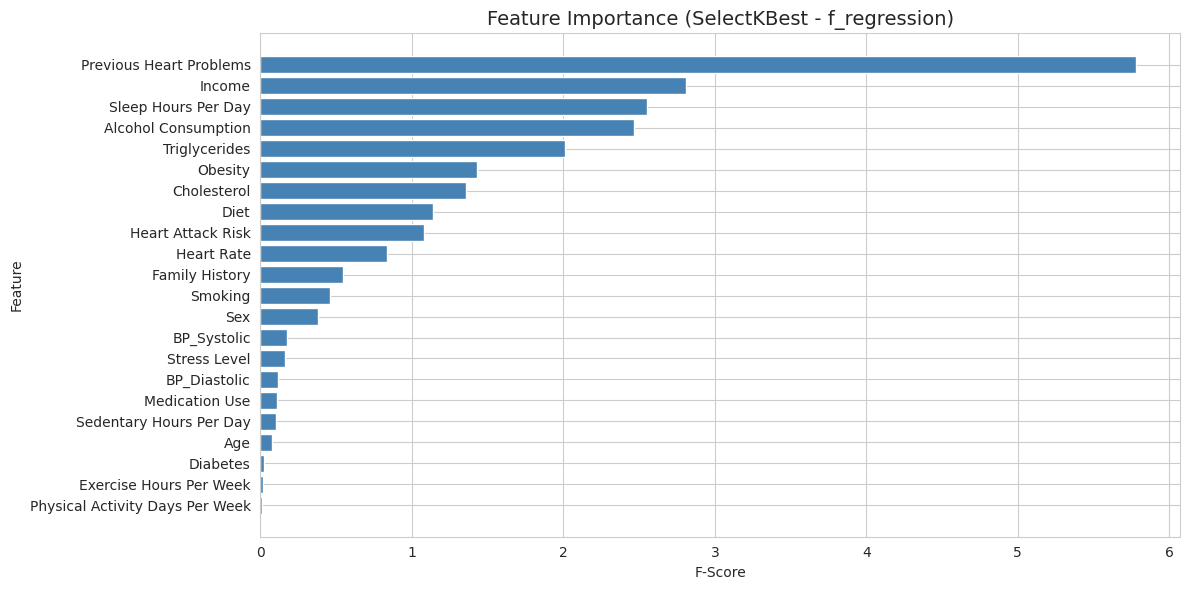

In [ ]:
# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_scores['Feature'], feature_scores['F-Score'], color='steelblue')
plt.xlabel('F-Score')
plt.ylabel('Feature')
plt.title('Feature Importance (SelectKBest - f_regression)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Select top features
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()
print(f'\nSelected Features ({len(selected_features)}):')
for i, f in enumerate(selected_features, 1):
    print(f'  {i}. {f}')

# Create new feature sets with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f'\nReduced feature set shape: {X_train_selected.shape}')


Selected Features (10):
  1. Cholesterol
  2. Heart Rate
  3. Obesity
  4. Alcohol Consumption
  5. Diet
  6. Previous Heart Problems
  7. Income
  8. Triglycerides
  9. Sleep Hours Per Day
  10. Heart Attack Risk

Reduced feature set shape: (7010, 10)


---
## Task 6: Final Models and Comparative Analysis

Rebuild both models using:
- Optimal hyperparameters from Task 4
- Selected features from Task 5

In [ ]:
# Final Model A: Ridge Regression with optimal hyperparameters and selected features
final_ridge = Ridge(**grid_search_ridge.best_params_)
final_ridge.fit(X_train_selected, y_train)

y_pred_ridge_final = final_ridge.predict(X_test_selected)

# Cross-validation score for final Ridge model
cv_scores_ridge = cross_val_score(final_ridge, X_train_selected, y_train, cv=5, scoring='r2')

print('=== Final Ridge Regression (Model A) ===')
print(f'CV R-squared: {cv_scores_ridge.mean():.4f} (+/- {cv_scores_ridge.std():.4f})')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge_final)):.4f}')
print(f'Test MAE: {mean_absolute_error(y_test, y_pred_ridge_final):.4f}')
print(f'Test R-squared: {r2_score(y_test, y_pred_ridge_final):.4f}')

=== Final Ridge Regression (Model A) ===
CV R-squared: -0.0008 (+/- 0.0025)
Test RMSE: 6.4148
Test MAE: 5.5465
Test R-squared: -0.0118


In [ ]:
# Final Model B: Random Forest with optimal hyperparameters and selected features
final_rf = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42)
final_rf.fit(X_train_selected, y_train)

y_pred_rf_final = final_rf.predict(X_test_selected)

# Cross-validation score for final RF model
cv_scores_rf = cross_val_score(final_rf, X_train_selected, y_train, cv=5, scoring='r2')

print('=== Final Random Forest Regressor (Model B) ===')
print(f'CV R-squared: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_final)):.4f}')
print(f'Test MAE: {mean_absolute_error(y_test, y_pred_rf_final):.4f}')
print(f'Test R-squared: {r2_score(y_test, y_pred_rf_final):.4f}')

=== Final Random Forest Regressor (Model B) ===
CV R-squared: -0.0015 (+/- 0.0021)
Test RMSE: 6.3900
Test MAE: 5.5207
Test R-squared: -0.0040


In [ ]:
# Final Comparison Table (as per Table 2 in instructions)
final_comparison = pd.DataFrame({
    'Model': ['Ridge Regression (Model A)', 'Random Forest Regressor (Model B)'],
    'Features Used': [f'Selected ({len(selected_features)})', f'Selected ({len(selected_features)})'],
    'CV Score (R2)': [cv_scores_ridge.mean(), cv_scores_rf.mean()],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_ridge_final)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf_final))
    ],
    'Test R-squared': [
        r2_score(y_test, y_pred_ridge_final),
        r2_score(y_test, y_pred_rf_final)
    ]
})

print('\n=== Table: Comparison of Final Regression Models ===')
print(final_comparison.to_string(index=False))


=== Table: Comparison of Final Regression Models ===
                            Model Features Used  CV Score (R2)  Test RMSE  Test R-squared
       Ridge Regression (Model A) Selected (10)      -0.000813   6.414839       -0.011812
Random Forest Regressor (Model B) Selected (10)      -0.001496   6.390041       -0.004004


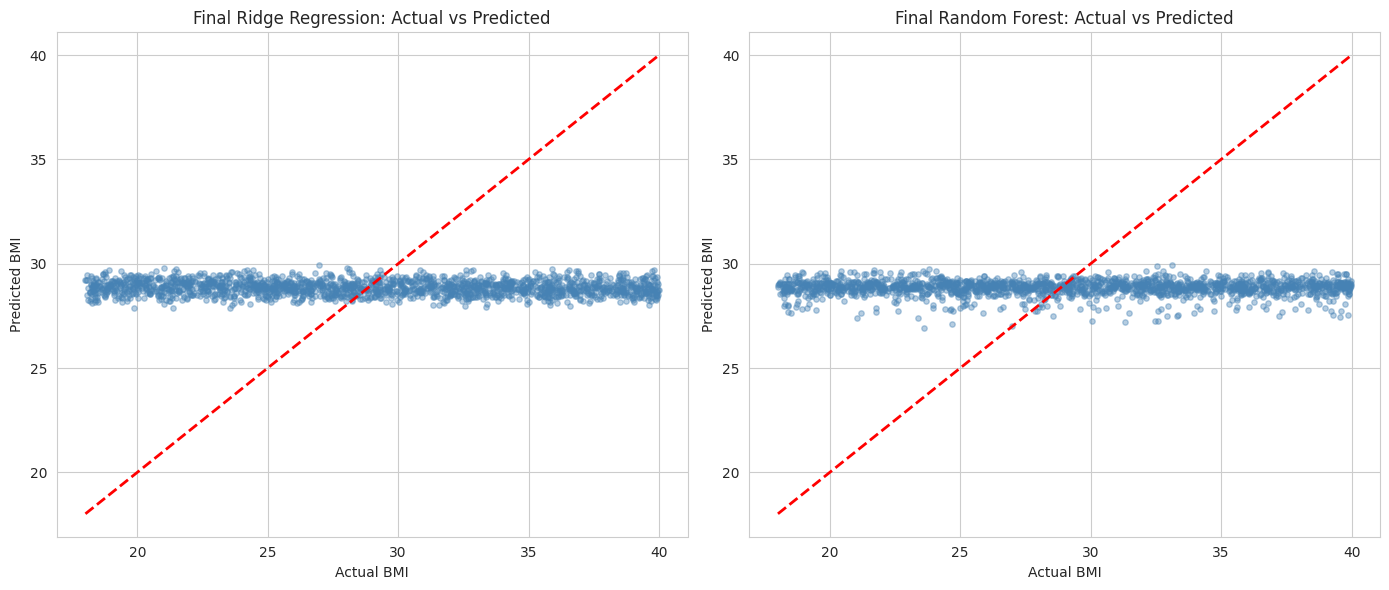

In [ ]:
# Visual comparison of final models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_ridge_final, alpha=0.4, s=15, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_title('Final Ridge Regression: Actual vs Predicted', fontsize=12)
axes[0].set_xlabel('Actual BMI')
axes[0].set_ylabel('Predicted BMI')

axes[1].scatter(y_test, y_pred_rf_final, alpha=0.4, s=15, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_title('Final Random Forest: Actual vs Predicted', fontsize=12)
axes[1].set_xlabel('Actual BMI')
axes[1].set_ylabel('Predicted BMI')

plt.tight_layout()
plt.show()